In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from load_data_test0 import load_arxiv_data
from preprocessing import clean_dataframe, basic_cleaning, STOPWORDS, nlp

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = load_arxiv_data()
print("raw shape:", df.shape)

df = clean_dataframe(df)
print("cleaned shape:", df.shape)

print(df.columns.tolist())
df.head()

raw shape: (2000, 12)

Cleaning data...
After dropping missing abstracts: 2000 papers. So removed 0
After dropping duplicate IDs: 2000 papers. So removed 0
After dropping duplicate abstracts: 1999 papers. So removed 1
After dropping empty abstracts: 1999 papers. So removed 0
After dropping short abstracts: 1996 papers. So removed 3
After dropping invalid years: 1996 papers. So removed 0

Summary of cleaning:
Total papers removed: 4
Final number of papers: 1996
cleaned shape: (1996, 12)
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions', 'year']


,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year
0,0704.3708,Bernat Corominas-Murtra BCM,Bernat Corominas-Murtra,Network statistics on early English Syntax: St...,"New abstract. Due to a mistake, abstract from ...",None,None,This paper includes a reflection on the role...,None,[cs.CL],"[v1, v2]",2007
1,0705.0693,Tshilidzi Marwala,Evan Hurwitz and Tshilidzi Marwala,Learning to Bluff,6 pages,None,None,The act of bluffing confounds game designers...,None,[cs.AI],[v1],2007
2,0705.1031,Tshilidzi Marwala,F.V. Nelwamondo and T. Marwala,Fuzzy Artmap and Neural Network Approach to On...,7 pages,None,None,An ensemble based approach for dealing with ...,None,[cs.AI],[v1],2007
3,0704.3433,Tshilidzi Marwala,Tshilidzi Marwala and Bodie Crossingham,Bayesian approach to rough set,"20 pages, 3 figures",None,None,This paper proposes an approach to training ...,None,[cs.AI],[v1],2007
4,0706.1137,Thierry Poibeau,"Amanda Bouffier (LIPN), Thierry Poibeau (LIPN)",Automatically Restructuring Practice Guideline...,None,Proceedings of Biomedical Natural Language Pro...,None,This paper describes a system capable of sem...,None,[cs.AI],[v1],2007


In [3]:
def preprocess_abstracts_batch(texts, batch_size=64):
    cleaned = []
    texts_cleaned = [basic_cleaning(text) for text in texts]

    for doc in tqdm(nlp.pipe(texts_cleaned, batch_size=batch_size), total=len(texts_cleaned)):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.text.lower() not in STOPWORDS
            and len(token.text) > 2
            and not token.is_space
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

df["cleaned_abstract"] = preprocess_abstracts_batch(df["abstract"].tolist())

  0%|          | 0/1996 [00:00<?, ?it/s]

In [4]:
import os
import load_data_test0

print("Current working directory of the notebook:")
print(os.getcwd())

print("The current actual path of the imported file - load_data_test0:")
print(load_data_test0.__file__)

Current working directory of the notebook:
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3
The current actual path of the imported file - load_data_test0:
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3\load_data_test0.py


In [5]:
df[["abstract", "cleaned_abstract"]].head(5)
#check the result of preprocessing

,abstract,cleaned_abstract
0,This paper includes a reflection on the role...,paper includes reflection role networks study ...
1,The act of bluffing confounds game designers...,act bluffing confounds game designers day natu...
2,An ensemble based approach for dealing with ...,ensemble based approach dealing missing data w...
3,This paper proposes an approach to training ...,paper proposes approach training rough set mod...
4,This paper describes a system capable of sem...,paper describes system capable semi automatica...


In [6]:
def assign_period(year):
    if 2007 <= year < 2012:
        return "2007-2011"
    elif 2012 <= year < 2017:
        return "2012-2016"
    elif 2017 <= year <= 2021:
        return "2017-2021"
    else:
        return None

df["period"] = df["year"].apply(assign_period)
df = df[df["period"].notna()].copy()
df["period"].value_counts().sort_index()

period
2007-2011    1268
2012-2016     728
Name: count, dtype: int64

In [7]:
df.to_pickle("person3_preprocessed_sample.pkl")
#Save intermediate results - to avoid having to re-run the preprocessing process again

In [8]:
#Create the LDA input matrix
texts = df["cleaned_abstract"].fillna("").tolist()

vectorizer = CountVectorizer(
    max_df=0.7,
    min_df=5,
    stop_words="english"
)

X = vectorizer.fit_transform(texts)

print("X shape:", X.shape)

X shape: (1996, 3435)


In [9]:
#Train a baseline LDA
lda = LatentDirichletAllocation(
    n_components=6,#first try six themes
    random_state=42,
    learning_method="batch"
)

doc_topic = lda.fit_transform(X)#The probability distribution of each abstract belonging to each topic
feature_names = vectorizer.get_feature_names_out()

print("doc_topic shape:", doc_topic.shape)

doc_topic shape: (1996, 6)


In [10]:
#Print the keywords for each topic
def print_topics(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_terms = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx}: {', '.join(top_terms)}")

print_topics(lda, feature_names)

Topic 0: language, paper, based, information, using, data, used, text, semantic, knowledge, fuzzy, model
Topic 1: learning, algorithm, data, problem, algorithms, model, method, based, using, performance, number, function
Topic 2: decision, based, logic, knowledge, paper, model, planning, systems, approach, reasoning, agent, framework
Topic 3: search, constraint, problems, problem, constraints, heuristic, domain, planning, information, paper, approach, based
Topic 4: inference, algorithm, models, networks, bayesian, variables, paper, algorithms, time, network, probabilistic, methods
Topic 5: sets, based, set, paper, rough, covering, new, results, grammar, sat, asp, matrix


In [11]:
#Assign a main topic to each article
df["dominant_topic"] = doc_topic.argmax(axis=1)
df[["year", "period", "dominant_topic", "cleaned_abstract"]].head(10)

,year,period,dominant_topic,cleaned_abstract
0,2007,2007-2011,0,paper includes reflection role networks study ...
1,2007,2007-2011,0,act bluffing confounds game designers day natu...
2,2007,2007-2011,1,ensemble based approach dealing missing data w...
3,2007,2007-2011,1,paper proposes approach training rough set mod...
4,2007,2007-2011,0,paper describes system capable semi automatica...
5,2007,2007-2011,0,paper survey large number informal definitions...
6,2007,2007-2011,2,representing reasoning qualitative temporal in...
7,2007,2007-2011,0,noise corruptions variations face images serio...
8,2007,2007-2011,1,paper presents bushing condition monitoring fr...
9,2007,2007-2011,2,idea symbolic controllers tries bridge gap top...


In [12]:
# Baseline 1 Topic Diversity Evaluation
def topic_diversity(model, feature_names, top_n=10):
    all_words = []
    for topic in model.components_:
        top_idx = topic.argsort()[:-top_n-1:-1]
        all_words.extend([feature_names[i] for i in top_idx])
    return len(set(all_words)) / len(all_words)

div1 = topic_diversity(lda, vectorizer.get_feature_names_out())
print(f"Baseline 1 Topic Diversity: {div1:.3f}")
print("A lower value indicates that there is more repetition of words among the topics, and the degree of distinction is poorer.")

Baseline 1 Topic Diversity: 0.733
A lower value indicates that there is more repetition of words among the topics, and the degree of distinction is poorer.


In [13]:
#View the distribution of topics at different time periods
topic_period = pd.crosstab(
    df["period"],
    df["dominant_topic"],
    normalize="index"
)

topic_period
#Value: The proportion of each topic during this period

dominant_topic,0,1,2,3,4,5
period,,,,,,
2007-2011,0.279968,0.273659,0.187697,0.126183,0.075710,0.056782
2012-2016,0.173077,0.259615,0.225275,0.050824,0.239011,0.052198


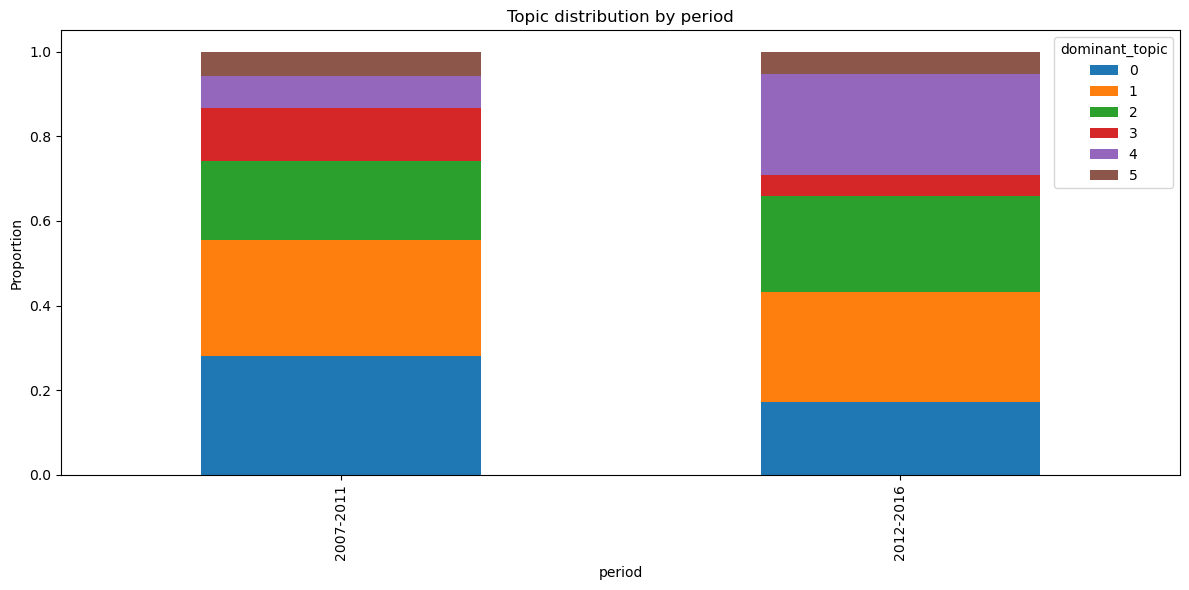

In [14]:
#Draw a stacked bar chart
topic_period.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [15]:
#Topics 0, 3, and 5 were higher in the previous period, while topics 2 and 4 were higher in the current period. Currently, the model has basic comparison capabilities.

In [16]:
#Defect: The interpretability of the topics is relatively weak. In the "words" section, there are many rather general academic terms (#However, many of the extracted topics are dominated by generic academic vocabulary, which reduces the interpretability)

In [17]:
#Improving LDA: Enhancing Interpretability

In [18]:
custom_stopwords = {
    "paper", "approach", "method", "methods", "model", "models",
    "problem", "problems", "algorithm", "algorithms",
    "based", "using", "use", "used", "proposed", "propose",
    "result", "results", "data", "set", "information",
    "function", "functions", "study", "present", "work"
}

In [19]:
#baseline2: Modified stop words + Parameters + Number of topics
vectorizer2 = CountVectorizer(
    max_df=0.6,
    min_df=10,
    stop_words="english",
    ngram_range=(1, 2)#easier to see phrases than individual words, and phrases are easier to explain.
)

X2 = vectorizer2.fit_transform(df["cleaned_abstract"].fillna(""))
feature_names2 = vectorizer2.get_feature_names_out()

#delete the column corresponding to the custom stop words once
keep_idx = [i for i, term in enumerate(feature_names2) if term not in custom_stopwords]
X2 = X2[:, keep_idx]
feature_names2 = feature_names2[keep_idx]

In [20]:
lda2 = LatentDirichletAllocation(
    n_components=6,#Similar to baseline 1, the control variables
    random_state=42,
    learning_method="batch"
)

doc_topic2 = lda2.fit_transform(X2)

In [21]:
print_topics(lda2, feature_names2)

Topic 0: sets, class, learning, time, distribution, rough, matrix, variables, covering, number, constraint, linear
Topic 1: knowledge, semantic, decision, systems, web, process, domain, user, rules, ontology, agents, temporal
Topic 2: learning, performance, new, different, text, words, word, machine, classification, analysis, recognition, training
Topic 3: search, planning, optimal, state, decision, time, value, solution, new, space, policy, number
Topic 4: learning, language, optimization, natural, grammar, new, online, task, processing, sentences, regression, natural language
Topic 5: logic, inference, fuzzy, probabilistic, theory, bayesian, networks, reasoning, programs, uncertainty, probability, belief


In [22]:
# Baseline 2 Topic Diversity Evaluation + Comparison with Baseline 1
div2 = topic_diversity(lda2, feature_names2)
print(f"Baseline 1 Topic Diversity: {div1:.3f}")
print(f"Baseline 2 Topic Diversity: {div2:.3f}")
print(f"Improvement percentage:: +{div2-div1:.3f}")
print("The bigrams of Baseline 2 and the custom stop words have enhanced the topic discrimination.")

#Side-by-side comparison table
comparison_rows = []
for topic_id in range(lda.n_components):
    top1 = [vectorizer.get_feature_names_out()[i]
            for i in lda.components_[topic_id].argsort()[:-9:-1]]
    top2 = [feature_names2[i]
            for i in lda2.components_[topic_id].argsort()[:-9:-1]]
    comparison_rows.append({
        "Topic": topic_id,
        "Baseline 1 (unigrams)": ", ".join(top1),
        "Baseline 2 (bigrams)":  ", ".join(top2)
    })

pd.DataFrame(comparison_rows)

Baseline 1 Topic Diversity: 0.733
Baseline 2 Topic Diversity: 0.900
Improvement percentage:: +0.167
The bigrams of Baseline 2 and the custom stop words have enhanced the topic discrimination.


,Topic,Baseline 1 (unigrams),Baseline 2 (bigrams)
0,0,"language, paper, based, information, using, da...","sets, class, learning, time, distribution, rou..."
1,1,"learning, algorithm, data, problem, algorithms...","knowledge, semantic, decision, systems, web, p..."
2,2,"decision, based, logic, knowledge, paper, mode...","learning, performance, new, different, text, w..."
3,3,"search, constraint, problems, problem, constra...","search, planning, optimal, state, decision, ti..."
4,4,"inference, algorithm, models, networks, bayesi...","learning, language, optimization, natural, gra..."
5,5,"sets, based, set, paper, rough, covering, new,...","logic, inference, fuzzy, probabilistic, theory..."


In [23]:
df["dominant_topic_v2"] = doc_topic2.argmax(axis=1)

topic_period_v2 = pd.crosstab(
    df["period"],
    df["dominant_topic_v2"],
    normalize="index"
)

topic_period_v2

dominant_topic_v2,0,1,2,3,4,5
period,,,,,,
2007-2011,0.103312,0.226341,0.236593,0.207413,0.123817,0.102524
2012-2016,0.092033,0.167582,0.166209,0.318681,0.087912,0.167582


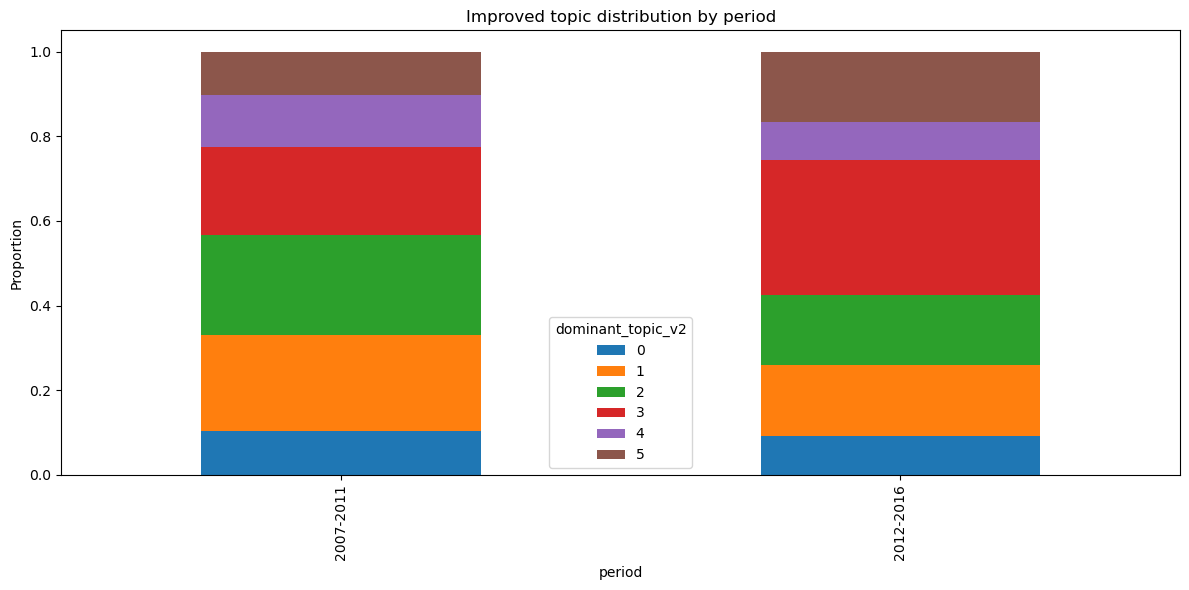

In [24]:
topic_period_v2.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Improved topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [25]:
#Test 2: It is clearly shown that in the earlier period, topic 1 (decision), topic 2 (text), and topic 0 (linear) accounted for a larger proportion. In the later period, topic 3 (time) and topic 5 (fuzzy) accounted for a larger proportion.

In [26]:
# Improvement: Enhance the quality of the Topic, and then expand the time coverage range (with the complete dataset).

In [27]:
# Baseline 1 (unigrams, k=6):
#   - The topic keywords are mainly composed of single words, with numerous generalized terms and poor interpretability.
#   - Example: The topic includes words such as "model, data, learning, system" which are of no distinction.
#
# Baseline 2 (bigrams + custom stop words, k=6):
#   - Phrases and expressions (such as "neural network", "decision tree") have clearer meanings.
#   - After customizing the stop words to filter out the common academic words, the topic becomes more focused.
#   - Under the same k value, the topic discrimination of Baseline 2 is significantly higher.
#
# It has been verified that "bigrams + custom stop words" is a better way to represent the text.
# The optimal value of k needs to be formally determined on the complete dataset.

In [28]:
topic_diff_v2 = topic_period_v2.loc["2012-2016"] - topic_period_v2.loc["2007-2011"]
topic_diff_v2.sort_values(ascending=False)

dominant_topic_v2
3    0.111268
5    0.065059
0   -0.011279
4   -0.035905
1   -0.058758
2   -0.070384
dtype: float64

In [29]:
df["topic_strength_v2"] = doc_topic2.max(axis=1)

for topic_id in range(6):
    print(f"\n===== Topic {topic_id} =====")
    top_docs = df[df["dominant_topic_v2"] == topic_id].sort_values(
        "topic_strength_v2", ascending=False
    ).head(3)

    for i, row in top_docs.iterrows():
        print(f"\nYear: {row['year']} | Period: {row['period']}")
        print("Title:", row["title"])
        print("Abstract snippet:", row["cleaned_abstract"][:300])


===== Topic 0 =====

Year: 2012 | Period: 2012-2016
Title: Geometric lattice structure of covering-based rough sets through
  matroids
Abstract snippet: covering based rough set theory useful tool deal inexact uncertain vague knowledge information systems geometric lattice widely used diverse fields especially search algorithm design plays important role covering reductions paper construct four geometric lattice structures covering based rough sets 

Year: 2012 | Period: 2012-2016
Title: Topological characterizations to three types of covering approximation
  operators
Abstract snippet: covering based rough set theory useful tool deal inexact uncertain vague knowledge information systems topology one important subjects mathematics provides mathematical tools interesting topics studying information systems rough sets paper present topological characterizations three types covering a

Year: 2012 | Period: 2012-2016
Title: Lattice structures of fixed points of the lower approximations of

In [30]:
topic_labels_v2 = {
    0: "Rough sets and knowledge representation",
    1: "Semantic systems, ontology and knowledge management",
    2: "Language processing, correction and summarisation",
    3: "Planning and decision-making under uncertainty",
    4: "Kernel methods and structured learning",
    5: "Logic programming and uncertain reasoning"
}

In [31]:
topic_period_v2_named = topic_period_v2.copy()
topic_period_v2_named.columns = [topic_labels_v2[c] for c in topic_period_v2_named.columns]
topic_period_v2_named

,Rough sets and knowledge representation,"Semantic systems, ontology and knowledge management","Language processing, correction and summarisation",Planning and decision-making under uncertainty,Kernel methods and structured learning,Logic programming and uncertain reasoning
period,,,,,,
2007-2011,0.103312,0.226341,0.236593,0.207413,0.123817,0.102524
2012-2016,0.092033,0.167582,0.166209,0.318681,0.087912,0.167582


In [32]:
comparison_notes = pd.DataFrame({
    "Model": ["Baseline 1", "Baseline 2"],
    "Topics": [6, 6],
    "Representation": ["Unigrams", "Unigrams + Bigrams"],
    "Stopword strategy": ["Default English", "Default + custom domain stopwords"],
    "Interpretability": ["Lower", "Higher"],
    "Topic redundancy": ["Higher", "Lower"],
    "Temporal contrast clarity": ["Moderate", "Moderate but clearer"]
})

comparison_notes

,Model,Topics,Representation,Stopword strategy,Interpretability,Topic redundancy,Temporal contrast clarity
0,Baseline 1,6,Unigrams,Default English,Lower,Higher,Moderate
1,Baseline 2,6,Unigrams + Bigrams,Default + custom domain stopwords,Higher,Lower,Moderate but clearer


In [33]:
#On a development sample, baseline 2 produced more interpretable topics than baseline 1, with lower topic redundancy and clearer temporal contrast.

In [34]:
topic_summary = pd.DataFrame({
    "Topic ID": [0, 1, 2, 3, 4, 5],
    "Label": [
        "Rough sets and knowledge representation",
        "Semantic systems, ontology and knowledge management",
        "Language processing, correction and summarisation",
        "Planning and decision-making under uncertainty",
        "Kernel methods and structured learning",
        "Logic programming and uncertain reasoning"
    ],
    "Change 2012-2016 minus 2007-2011": [
        topic_diff_v2[0],
        topic_diff_v2[1],
        topic_diff_v2[2],
        topic_diff_v2[3],
        topic_diff_v2[4],
        topic_diff_v2[5]
    ]
})

topic_summary.sort_values("Change 2012-2016 minus 2007-2011", ascending=False)

,Topic ID,Label,Change 2012-2016 minus 2007-2011
3,3,Planning and decision-making under uncertainty,0.111268
5,5,Logic programming and uncertain reasoning,0.065059
0,0,Rough sets and knowledge representation,-0.011279
4,4,Kernel methods and structured learning,-0.035905
1,1,"Semantic systems, ontology and knowledge manag...",-0.058758
2,2,"Language processing, correction and summarisation",-0.070384


In [35]:
#Formal and complete data set analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_distances

# Directly load the officially preprocessed dataset
df = pd.read_pickle("data_preprocessed.pkl")

period_order = ["2007-2011", "2012-2016", "2017-2021"]

print("Shape:", df.shape)
print(df["period"].value_counts().sort_index())

Shape: (27121, 14)
period
2007-2011     1268
2012-2016     5542
2017-2021    20311
Name: count, dtype: int64


In [37]:
custom_stopwords = {
    "paper", "approach", "method", "methods", "model", "models",
    "problem", "problems", "algorithm", "algorithms",
    "based", "using", "use", "used", "proposed", "propose",
    "result", "results", "data", "set", "information",
    "function", "functions", "study", "present", "work"
}

vectorizer = CountVectorizer(
    max_df=0.6,
    min_df=10,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["cleaned_abstract"].fillna(""))
feature_names = vectorizer.get_feature_names_out()

# Filter custom stop words
keep_idx = [i for i, t in enumerate(feature_names) if t not in custom_stopwords]
X = X[:, keep_idx]
feature_names = feature_names[keep_idx]

print("X shape:", X.shape)

X shape: (27121, 30155)


In [38]:
#This code will only run when it is needed to be installed.
#import subprocess
#subprocess.run(["pip", "install", "gensim"], check=True)

d:\py\Anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


k=4: coherence=0.3847
k=5: coherence=0.3988
k=6: coherence=0.4090
k=7: coherence=0.3987
k=8: coherence=0.4502
k=10: coherence=0.4427
k=12: coherence=0.4561
k=14: coherence=0.4478
k=16: coherence=0.4293


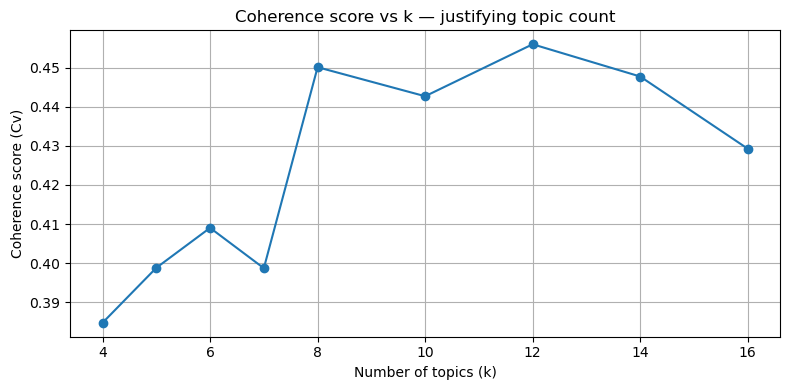


Best k = 12


In [39]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

tokenised = [text.split() for text in df["cleaned_abstract"].fillna("")]
dictionary = corpora.Dictionary(tokenised)
corpus_gensim = [dictionary.doc2bow(doc) for doc in tokenised]
#Specify several topics and evaluate the quality after using different themes.
k_values = [4, 5, 6, 7, 8, 10, 12, 14, 16]
coherence_scores = []

for k in k_values:
    lda_g = gensim.models.LdaModel(
        corpus=corpus_gensim, id2word=dictionary,
        num_topics=k, random_state=42, passes=5
    )
    cm = CoherenceModel(model=lda_g, texts=tokenised,
                        dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k}: coherence={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, coherence_scores, marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (Cv)")
plt.title("Coherence score vs k — justifying topic count")
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_values[coherence_scores.index(max(coherence_scores))]
print(f"\nBest k = {best_k}")

#The result shows that K = 12 is the peak value and is currently the most suitable number of topics.

In [40]:
# The k selected by using "coherence"
FINAL_K = best_k 

lda_final = LatentDirichletAllocation(
    n_components=FINAL_K,
    random_state=42,
    learning_method="batch"
)

doc_topic = lda_final.fit_transform(X)
print("doc_topic shape:", doc_topic.shape)

# Print topic keywords
def print_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Topic {idx}: {', '.join(top)}")

print_topics(lda_final, feature_names)

doc_topic shape: (27121, 12)
Topic 0: knowledge, text, entity, language, tasks, task, bert, pre, extraction, entities, trained, context
Topic 1: word, semantic, words, embeddings, representations, embedding, clustering, similarity, vector, representation, learning, knowledge
Topic 2: learning, training, classification, graph, datasets, performance, domain, supervised, label, labels, existing, dataset
Topic 3: time, systems, research, machine, human, intelligence, machine learning, learning, decision, different, artificial, real
Topic 4: search, optimization, optimal, number, time, linear, learning, space, new, distribution, cost, solution
Topic 5: detection, social, analysis, features, dataset, learning, media, sentiment, user, classification, prediction, users
Topic 6: question, dialogue, generation, answer, questions, knowledge, dataset, human, reasoning, answering, task, multi
Topic 7: task, sentence, state, art, state art, parsing, semantic, sequence, word, dependency, sentences, n

In [41]:
# Aliases for final model outputs
X_final = X
doc_topic_final = doc_topic
feature_names_final = feature_names

print("Final aliases created.")
print("doc_topic_final shape:", doc_topic_final.shape)

Final aliases created.
doc_topic_final shape: (27121, 12)


In [42]:
# Re-add the complete probability distribution to df
for i in range(FINAL_K):
    df[f"topic_{i}_prob"] = doc_topic[:, i]

topic_cols = [f"topic_{i}_prob" for i in range(FINAL_K)]
period_avg = df.groupby("period")[topic_cols].mean().reindex(period_order)

print(period_avg)

           topic_0_prob  topic_1_prob  topic_2_prob  topic_3_prob  \
period                                                              
2007-2011      0.019901      0.089041      0.036888      0.173128   
2012-2016      0.030012      0.077892      0.056237      0.121755   
2017-2021      0.085928      0.057783      0.105323      0.108274   

           topic_4_prob  topic_5_prob  topic_6_prob  topic_7_prob  \
period                                                              
2007-2011      0.246645      0.037962      0.037292      0.028414   
2012-2016      0.190253      0.040747      0.031367      0.045620   
2017-2021      0.078813      0.065754      0.071262      0.069002   

           topic_8_prob  topic_9_prob  topic_10_prob  topic_11_prob  
period                                                               
2007-2011      0.023393      0.044070       0.212931       0.050333  
2012-2016      0.055081      0.069160       0.231395       0.050481  
2017-2021      0.104299     

Topic label reference table:


,Topic ID,Meaning
0,T0,Knowledge extraction and NER
1,T1,Word semantics and embeddings
2,T2,Graph-based classification and supervised lear...
3,T3,AI systems and machine intelligence
4,T4,Search and optimisation
5,T5,Social media analytics and sentiment classific...
6,T6,Question answering and dialogue generation
7,T7,Parsing and semantic sequence modelling
8,T8,Deep learning and neural networks
9,T9,Machine translation and multilingual NLP


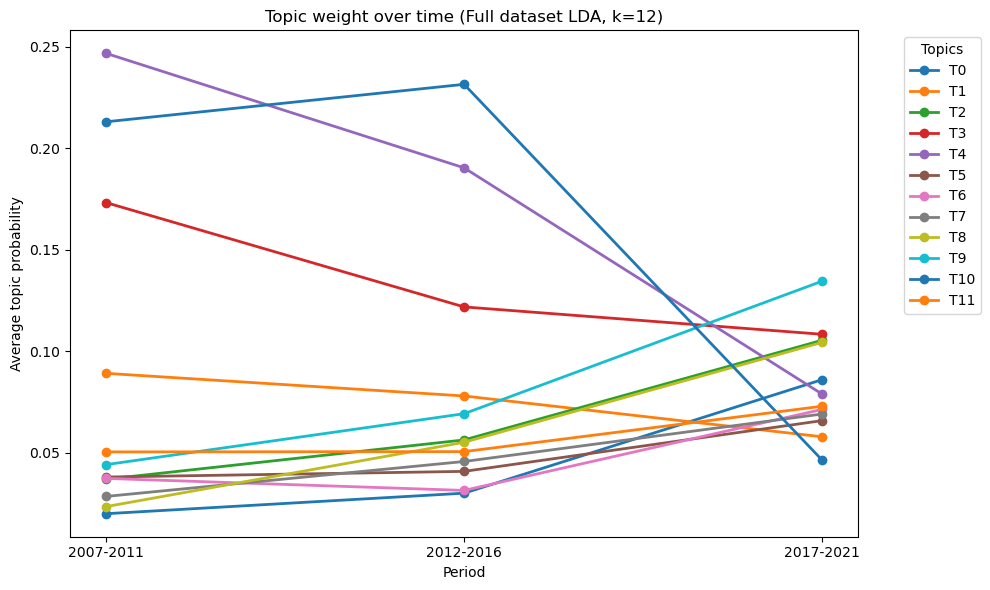

In [43]:
# Short labels for plotting
topic_labels_short = {
    0: "T0",
    1: "T1",
    2: "T2",
    3: "T3",
    4: "T4",
    5: "T5",
    6: "T6",
    7: "T7",
    8: "T8",
    9: "T9",
    10: "T10",
    11: "T11"
}

# Full labels for interpretation/report
topic_labels_full = {
    0: "Knowledge extraction and NER",
    1: "Word semantics and embeddings",
    2: "Graph-based classification and supervised learning",
    3: "AI systems and machine intelligence",
    4: "Search and optimisation",
    5: "Social media analytics and sentiment classification",
    6: "Question answering and dialogue generation",
    7: "Parsing and semantic sequence modelling",
    8: "Deep learning and neural networks",
    9: "Machine translation and multilingual NLP",
    10: "Probabilistic inference and logical reasoning",
    11: "Reinforcement learning and decision agents"
}

# Topic label lookup table
topic_label_table = pd.DataFrame({
    "Topic ID": [topic_labels_short[i] for i in range(FINAL_K)],
    "Meaning": [topic_labels_full[i] for i in range(FINAL_K)]
})

print("Topic label reference table:")
display(topic_label_table)

# Rename columns for plotting (use short labels only)
period_avg_named = period_avg.copy()
period_avg_named.columns = [topic_labels_short[i] for i in range(FINAL_K)]

# Line chart
fig, ax = plt.subplots(figsize=(10, 6))
for col in period_avg_named.columns:
    ax.plot(period_order, period_avg_named[col], marker="o", linewidth=2, label=col)

ax.set_title(f"Topic weight over time (Full dataset LDA, k={FINAL_K})")
ax.set_ylabel("Average topic probability")
ax.set_xlabel("Period")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Topics")
plt.tight_layout()
plt.show()

Dominant topic distribution by period:


,T0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11
period,,,,,,,,,,,,
2007-2011,0.009464,0.084385,0.031546,0.179022,0.307571,0.027603,0.018139,0.022082,0.009464,0.043375,0.237382,0.029968
2012-2016,0.026344,0.072357,0.047636,0.117827,0.211115,0.036629,0.019848,0.041140,0.046012,0.077228,0.265789,0.038073
2017-2021,0.089311,0.049333,0.106346,0.106740,0.075723,0.063709,0.075624,0.062134,0.104328,0.156418,0.037270,0.073064


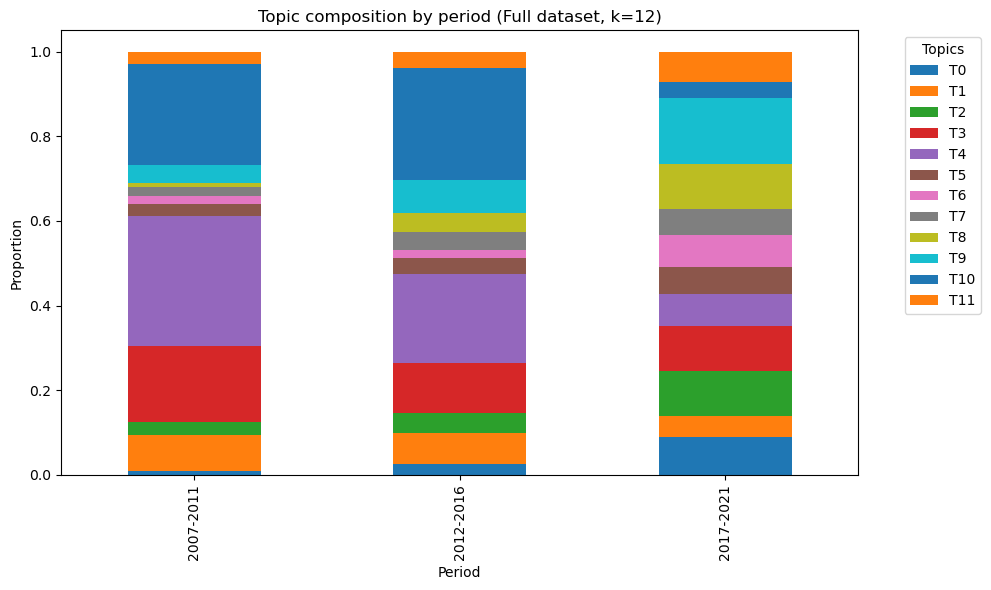

In [44]:
# Full-data dominant-topic distribution by period
df["dominant_topic_final"] = doc_topic_final.argmax(axis=1)

topic_period_final = pd.crosstab(
    df["period"],
    df["dominant_topic_final"],
    normalize="index"
).reindex(period_order)

# Use short labels for plotting
topic_period_final_named = topic_period_final.copy()
topic_period_final_named.columns = [topic_labels_short[i] for i in range(FINAL_K)]

print("Dominant topic distribution by period:")
display(topic_period_final_named)

# Stacked bar chart
ax = topic_period_final_named.plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_title(f"Topic composition by period (Full dataset, k={FINAL_K})")
ax.set_ylabel("Proportion")
ax.set_xlabel("Period")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Topics")
plt.tight_layout()
plt.show()

In [45]:
# Dynamically obtain the real period in the data
periods = sorted(df['period'].unique())
print(f"Successful detection of real periods: {periods}")

Successful detection of real periods: ['2007-2011', '2012-2016', '2017-2021']


In [46]:
from sklearn.metrics import adjusted_rand_score

seed_results = {}
for seed in [42, 0, 123]:
    m = LatentDirichletAllocation(n_components=FINAL_K, random_state=seed, learning_method="batch")
    seed_results[seed] = m.fit_transform(X).argmax(axis=1)

ari_a = adjusted_rand_score(seed_results[42], seed_results[0])
ari_b = adjusted_rand_score(seed_results[42], seed_results[123])
print(f"ARI (seed 42 vs 0):   {ari_a:.3f}")
print(f"ARI (seed 42 vs 123): {ari_b:.3f}")
print("An ARI value close to 1 indicates stability; an ARI value close to 0 indicates sensitivity to the seed, confirming the instability hypothesis.")

ARI (seed 42 vs 0):   0.271
ARI (seed 42 vs 123): 0.207
An ARI value close to 1 indicates stability; an ARI value close to 0 indicates sensitivity to the seed, confirming the instability hypothesis.


In [47]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

# The central vector of each period
centroids = np.array([
    doc_topic_final[df["period"] == p].mean(axis=0)
    for p in period_order
])

# Store the distances as an array instead of just printing them
n = len(period_order)
distance_array = np.zeros((n, n))  # 3x3

print("Cosine distances between all period pairs:")
for i in range(n):
    for j in range(i + 1, n):
        d = cosine_distances(
            centroids[i].reshape(1, -1),
            centroids[j].reshape(1, -1)
        )[0][0]
        distance_array[i][j] = d
        distance_array[j][i] = d  # Symmetric matrix
        print(f"{period_order[i]} vs {period_order[j]}: Distance = {d:.4f}")

print("\ndistance_array:\n", distance_array)

# Save File
np.save('lda_centroids.npy', centroids)       # shape: (3, n_topics)
np.save('lda_period_distances.npy', distance_array)  # shape: (3, 3)
print("\n 保存 lda_centroids.npy 和 lda_period_distances.npy")

Cosine distances between all period pairs:
2007-2011 vs 2012-2016: Distance = 0.0270
2007-2011 vs 2017-2021: Distance = 0.3403
2012-2016 vs 2017-2021: Distance = 0.2733

distance_array:
 [[0.         0.02703988 0.34027588]
 [0.02703988 0.         0.27330962]
 [0.34027588 0.27330962 0.        ]]

 保存 lda_centroids.npy 和 lda_period_distances.npy


In [48]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon

period_order = ["2007-2011", "2012-2016", "2017-2021"]

# Re-calculate the distribution of topic_period in the formal dataset (using doc_topic_final, which is the result of FINAL_K)
df["dominant_topic_final"] = doc_topic_final.argmax(axis=1)
topic_period_final = pd.crosstab(
    df["period"],
    df["dominant_topic_final"],
    normalize="index"
).reindex(period_order)

# File 1: Distribution Matrix (Exported with Short Labels)
topic_period_final_export = topic_period_final.copy()
topic_period_final_export.columns = [topic_labels_short[i] for i in range(FINAL_K)]

topic_period_final_export.to_csv('lda_period_topics.csv')
print("File 1 saved: lda_period_topics.csv")
print(topic_period_final_export)

# File 2: JS Divergence
lda_distances = []
for i in range(len(period_order) - 1):
    p1 = topic_period_final.loc[period_order[i]].values
    p2 = topic_period_final.loc[period_order[i+1]].values
    js = jensenshannon(p1, p2)
    lda_distances.append(round(float(js), 6))
    print(f"{period_order[i]} -- {period_order[i+1]}: JS = {js:.4f}")

np.save('lda_js_distances.npy', lda_distances)
print("File 2 saved: lda_js_distances.npy --", lda_distances)

# File 3: Topic Keywords
feature_names_arr = np.array(feature_names_final)
topic_words = {}

for topic_idx, topic in enumerate(lda_final.components_):
    top_idx = topic.argsort()[:-13:-1]
    col_name = topic_labels_short[topic_idx]   # T0/T1/T2
    topic_words[col_name] = feature_names_arr[top_idx].tolist()
    print(f"{col_name}: {', '.join(feature_names_arr[top_idx][:8])}")

pd.DataFrame(topic_words).to_csv('lda_topic_words.csv', index=False)
print("File 3 saved: lda_topic_words.csv")

File 1 saved: lda_period_topics.csv
                 T0        T1        T2        T3        T4        T5  \
period                                                                  
2007-2011  0.009464  0.084385  0.031546  0.179022  0.307571  0.027603   
2012-2016  0.026344  0.072357  0.047636  0.117827  0.211115  0.036629   
2017-2021  0.089311  0.049333  0.106346  0.106740  0.075723  0.063709   

                 T6        T7        T8        T9       T10       T11  
period                                                                 
2007-2011  0.018139  0.022082  0.009464  0.043375  0.237382  0.029968  
2012-2016  0.019848  0.041140  0.046012  0.077228  0.265789  0.038073  
2017-2021  0.075624  0.062134  0.104328  0.156418  0.037270  0.073064  
2007-2011 -- 2012-2016: JS = 0.1490
2012-2016 -- 2017-2021: JS = 0.3290
File 2 saved: lda_js_distances.npy -- [0.149044, 0.329029]
T0: knowledge, text, entity, language, tasks, task, bert, pre
T1: word, semantic, words, embeddings, repres

In [49]:
# Calculate the silhouette using the final version of the topic distribution and the period labels.
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, silhouette_samples

le = LabelEncoder()
y_period = le.fit_transform(df["period"])

overall_sil = silhouette_score(doc_topic_final, y_period, metric="cosine")
print(f"Overall silhouette score (topic space): {overall_sil:.4f}")

sample_sil = silhouette_samples(doc_topic_final, y_period, metric="cosine")

silhouette_by_period = (
    pd.DataFrame({
        "period": df["period"],
        "silhouette": sample_sil
    })
    .groupby("period")["silhouette"]
    .mean()
    .reindex(period_order)
)

print("\nAverage silhouette by period:")
display(silhouette_by_period.to_frame(name="mean_silhouette"))

Overall silhouette score (topic space): 0.0029

Average silhouette by period:


,mean_silhouette
period,
2007-2011,0.057228
2012-2016,-0.070402
2017-2021,0.019547
